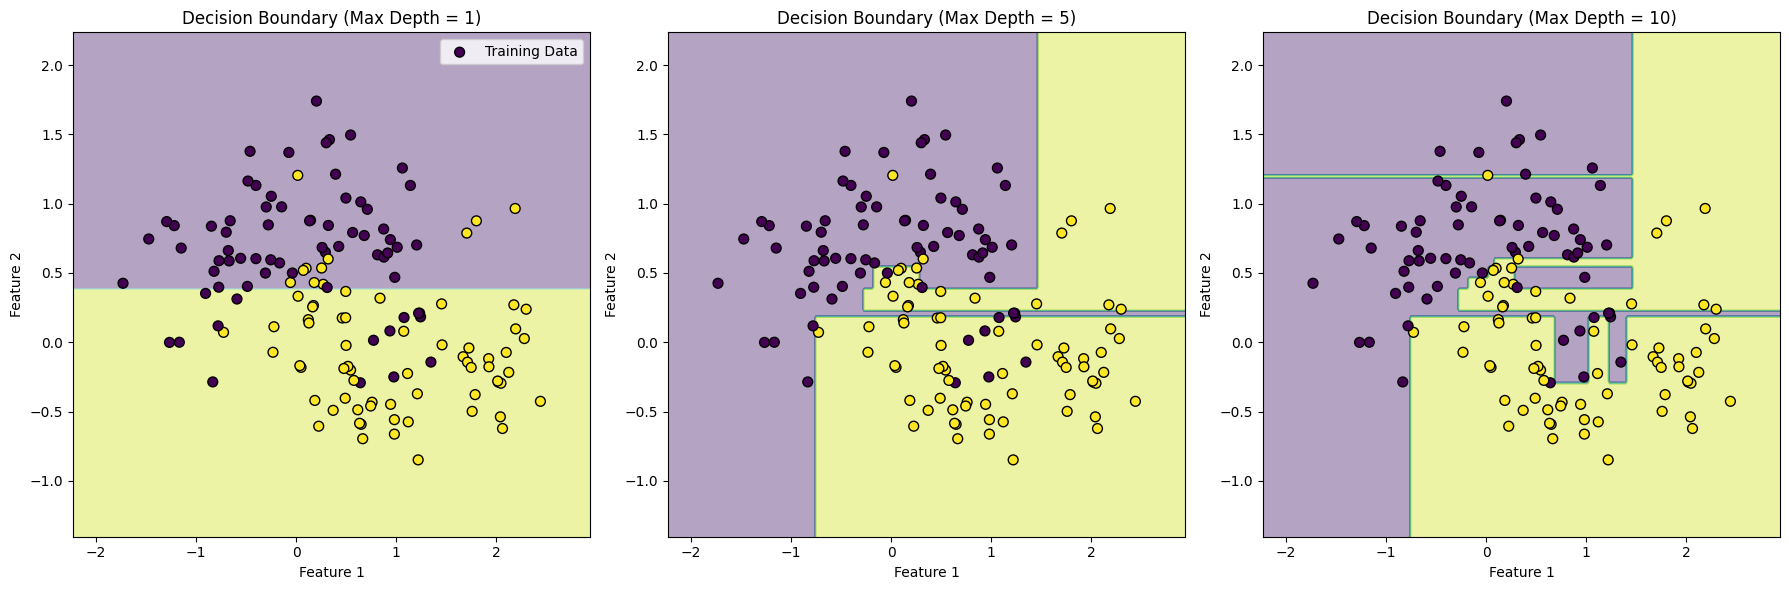

In [ ]:
selected_depths = [1, 5, 10]

plt.figure(figsize=(18, 6))

for i, depth in enumerate(selected_depths):
    # Initialize and train the Decision Tree Classifier
    dt_classifier = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_classifier.fit(X_train, y_train)

    # Create a meshgrid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    # Predict on the meshgrid
    Z = dt_classifier.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the decision boundary and training data
    plt.subplot(1, len(selected_depths), i + 1)
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='viridis')
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=50, cmap='viridis', edgecolors='k', label='Training Data')

    plt.title(f"Decision Boundary (Max Depth = {depth})")
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    if i == 0: # Add legend only to the first subplot to avoid repetition
        plt.legend()

plt.tight_layout()
plt.show()

Model Accuracy on Test Set: 1.0000



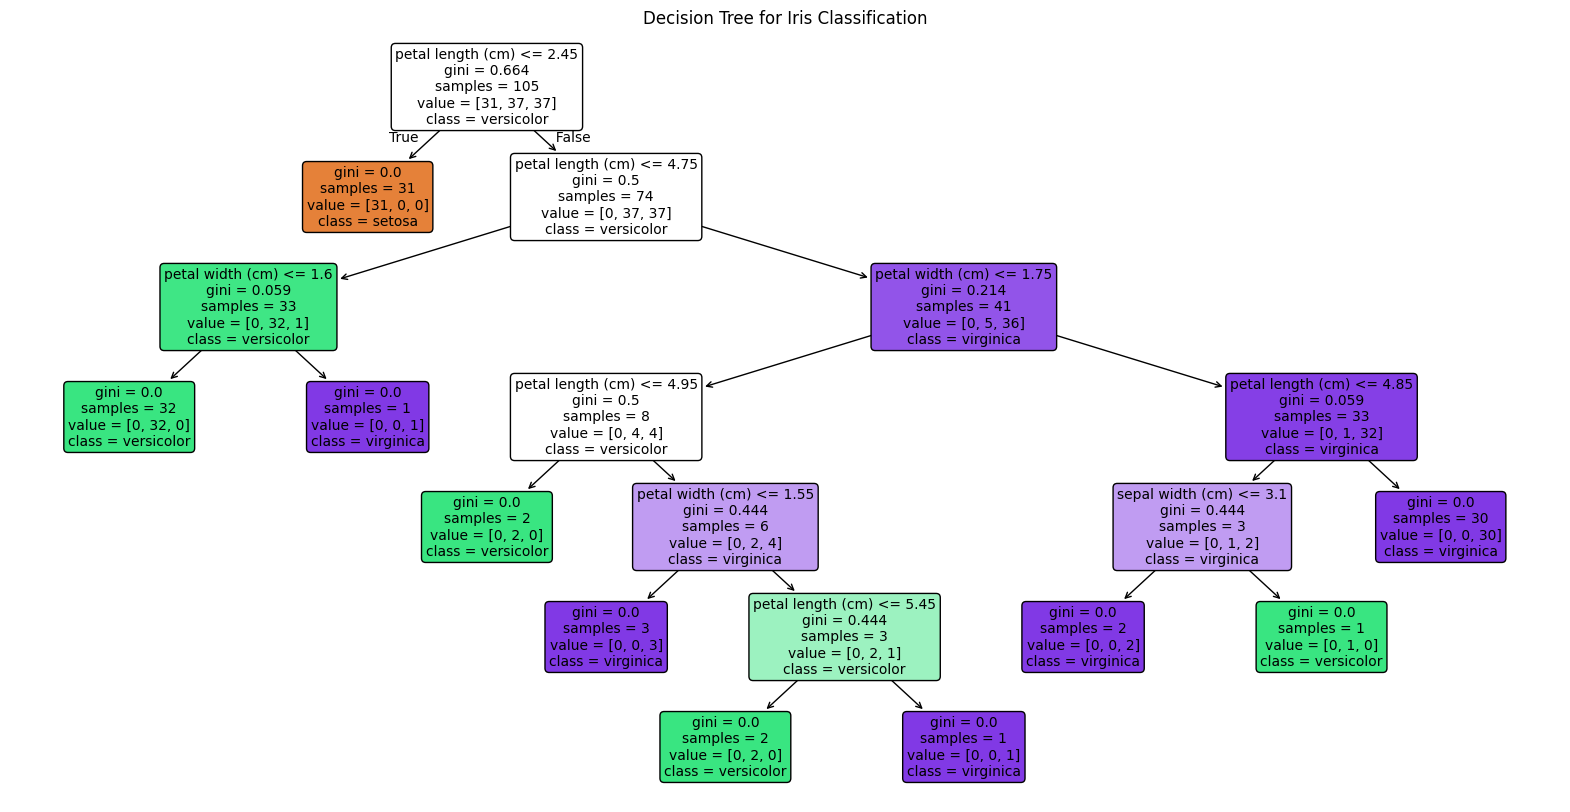

Features of the sample: [6.1 2.8 4.7 1.2]
Actual Species: versicolor
Predicted Species: versicolor


In [ ]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 1. Load the Iris dataset
# The Iris dataset is a classic for classification and contains measurements
# of different iris flower species.
iris = load_iris()
X = iris.data  # Features (Sepal Length, Sepal Width, Petal Length, Petal Width)
y = iris.target  # Target (Species: Setosa, Versicolor, Virginica)
feature_names = iris.feature_names
target_names = iris.target_names

# 2. Split the data into training and testing sets
# This is crucial to evaluate the model's performance on unseen data.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3. Initialize and Train the Decision Tree Classifier
# We'll use the 'gini' criterion for measuring the quality of a split.
dt_classifier = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_classifier.fit(X_train, y_train)

# 4. Make Predictions
y_pred = dt_classifier.predict(X_test)

# 5. Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy on Test Set: {accuracy:.4f}\n")

# 6. Visualize the Decision Tree
# The plot_tree function from sklearn is used for visualization.

plt.figure(figsize=(20, 10))
# The filled=True argument colors the nodes according to the majority class.
# rounded=True makes the boxes rounded.
# feature_names and class_names provide descriptive labels.
plot_tree(
    dt_classifier,
    feature_names=feature_names,
    class_names=target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree for Iris Classification")
plt.show()

# 7. Demonstrate a Single Prediction (optional but illustrative)
# Let's take the first sample from the test set
sample_features = X_test[0].reshape(1, -1)
prediction = dt_classifier.predict(sample_features)
predicted_species = target_names[prediction[0]]

print(f"Features of the sample: {sample_features[0]}")
print(f"Actual Species: {target_names[y_test[0]]}")
print(f"Predicted Species: {predicted_species}")

Model Accuracy on Test Set: 0.8333



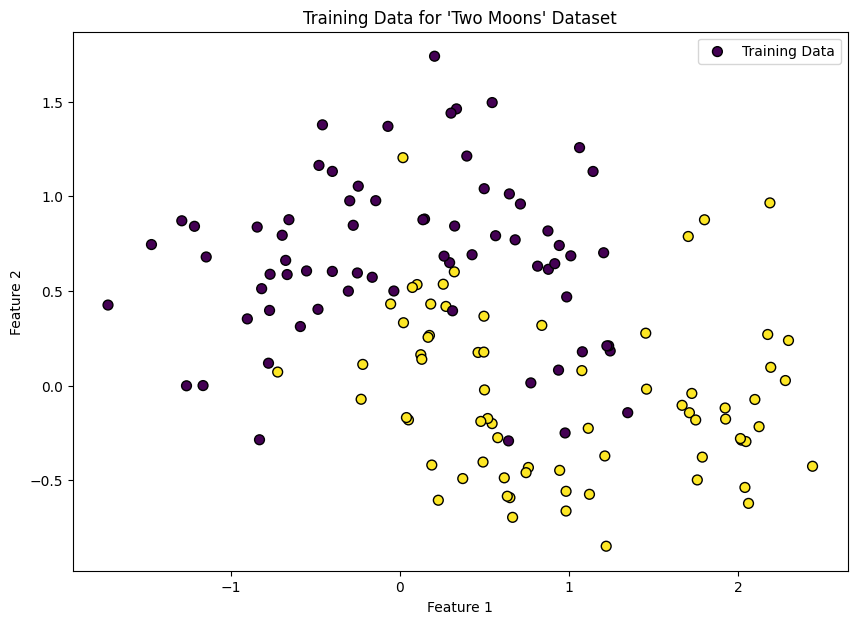

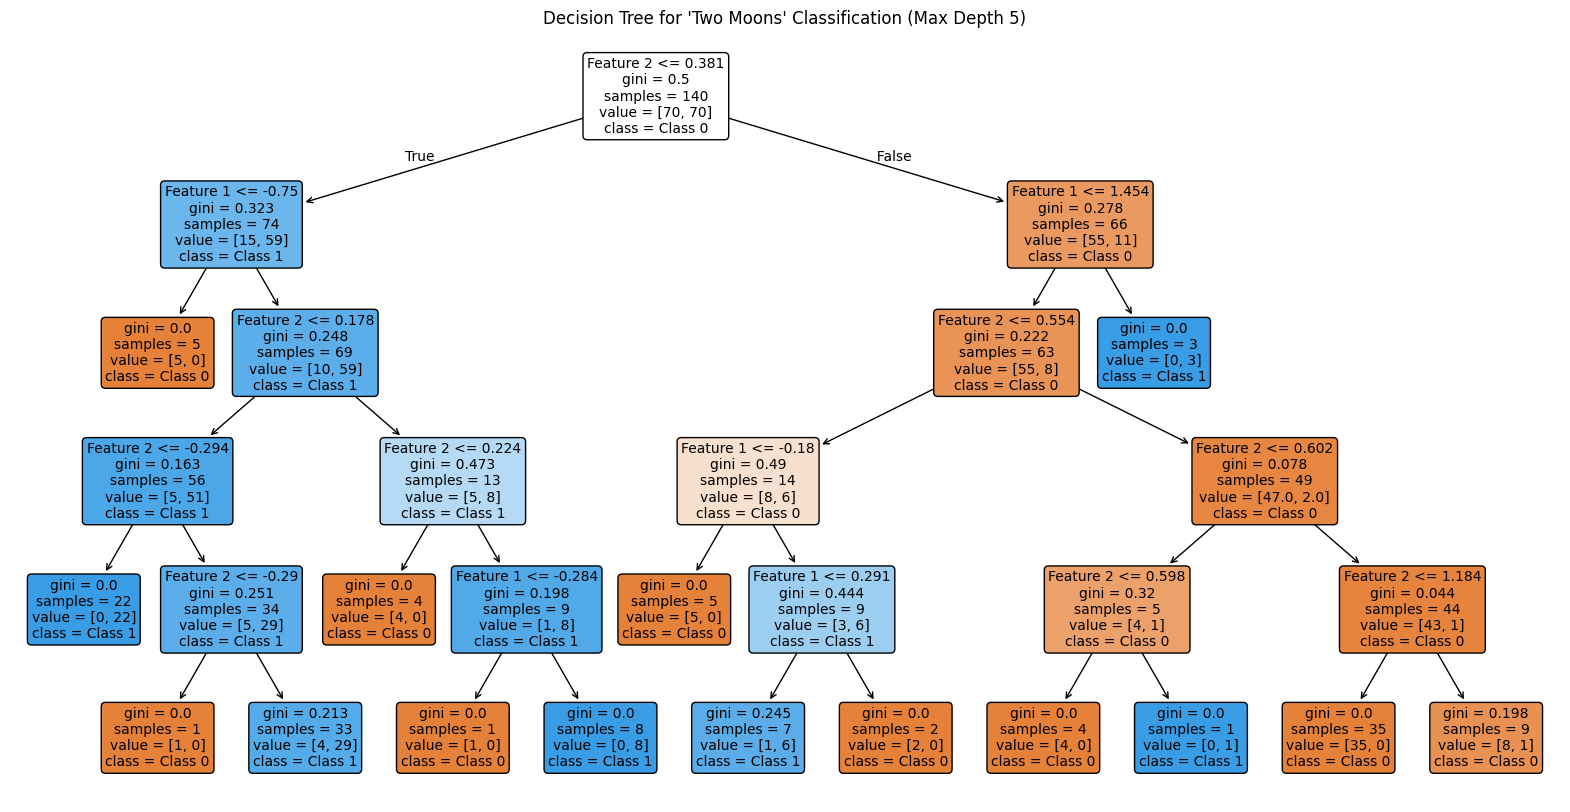

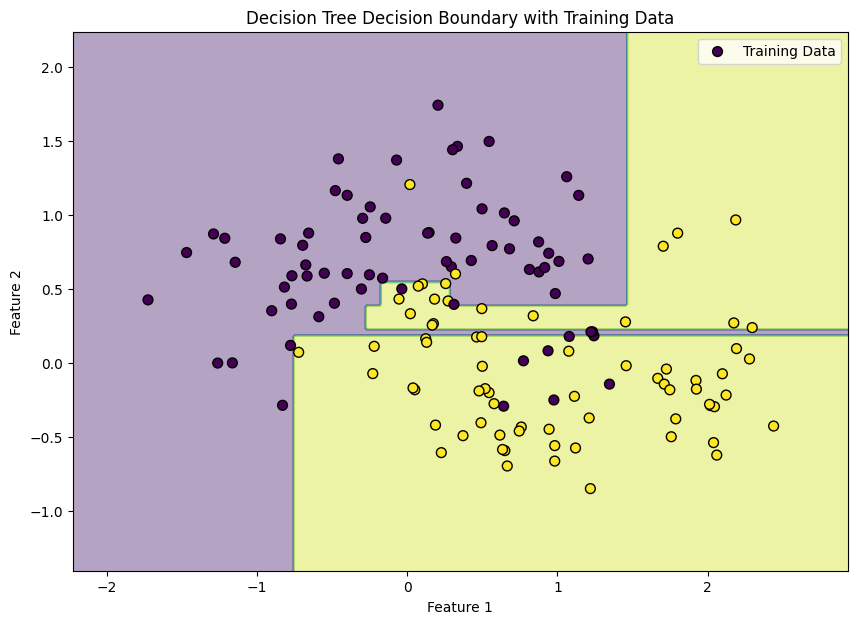

In [ ]:
import pandas as pd
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# 1. Generate a synthetic 'two moons' dataset
# This dataset is good for illustrating non-linear decision boundaries.
X, y = make_moons(n_samples=200, noise=0.3, random_state=42)

# For visualization later, let's give the features generic names
feature_names = ['Feature 1', 'Feature 2']
class_names = ['Class 0', 'Class 1']

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y # stratify ensures equal class distribution
)

# 3. Initialize and Train the Decision Tree Classifier
# We can play with 'max_depth' to control the complexity of the tree.
# A deeper tree can capture more complex patterns but risks overfitting.
dt_classifier = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_classifier.fit(X_train, y_train)

# 4. Make Predictions
y_pred = dt_classifier.predict(X_test)

# 5. Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy on Test Set: {accuracy:.4f}\n")



# 7. Visualize the Training Data
plt.figure(figsize=(10, 7))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=50, cmap='viridis', edgecolors='k', label='Training Data')
plt.title("Training Data for 'Two Moons' Dataset")
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.legend()
plt.show()

# 6. Visualize the Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(
    dt_classifier,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree for 'Two Moons' Classification (Max Depth 5)")
plt.show()

# 8. Visualize the Training Data and Decision Boundary
plt.figure(figsize=(10, 7))

# Create a meshgrid to plot the decision boundary
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = dt_classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the contour lines
plt.contourf(xx, yy, Z, alpha=0.4, cmap='viridis')
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=50, cmap='viridis', edgecolors='k', label='Training Data')

plt.title("Decision Tree Decision Boundary with Training Data")
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.legend()
plt.show()

# Task
Analyze the impact of `max_depth` on the Decision Tree model by training and evaluating models with different `max_depth` values, visualizing the accuracy vs. `max_depth`, and visualizing the decision boundaries for selected `max_depth` values.

## Define `max depth` values to test

### Subtask:
Choose a range of `max_depth` values to experiment with.


**Reasoning**:
Create a list of max_depth values to use for experimentation.



In [ ]:
max_depth_values = list(range(1, 16))
print(f"Selected max_depth values: {max_depth_values}")

Selected max_depth values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]


## Train and evaluate for each `max depth`

### Subtask:
Iterate through the chosen `max_depth` values, train a Decision Tree model for each, evaluate its accuracy on the test set, and store the results.


**Reasoning**:
The instructions require iterating through different max_depth values, training a model for each, evaluating accuracy, and storing the results. This can be done in a single code block.



In [ ]:
accuracy_scores = []
for depth in max_depth_values:
    dt_classifier = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_classifier.fit(X_train, y_train)
    y_pred = dt_classifier.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)

print("Accuracy scores for each max_depth:")
for depth, acc in zip(max_depth_values, accuracy_scores):
    print(f"  max_depth={depth}: {acc:.4f}")

Accuracy scores for each max_depth:
  max_depth=1: 0.8333
  max_depth=2: 0.8667
  max_depth=3: 0.8667
  max_depth=4: 0.8167
  max_depth=5: 0.8333
  max_depth=6: 0.8333
  max_depth=7: 0.8167
  max_depth=8: 0.8167
  max_depth=9: 0.8000
  max_depth=10: 0.8000
  max_depth=11: 0.8000
  max_depth=12: 0.8000
  max_depth=13: 0.8000
  max_depth=14: 0.8000
  max_depth=15: 0.8000


## Visualize accuracy vs. `max depth`

### Subtask:
Create a plot showing how the model accuracy changes with different `max_depth` values. This helps identify potential overfitting or underfitting.


**Reasoning**:
Create a plot to visualize the relationship between max_depth and accuracy.



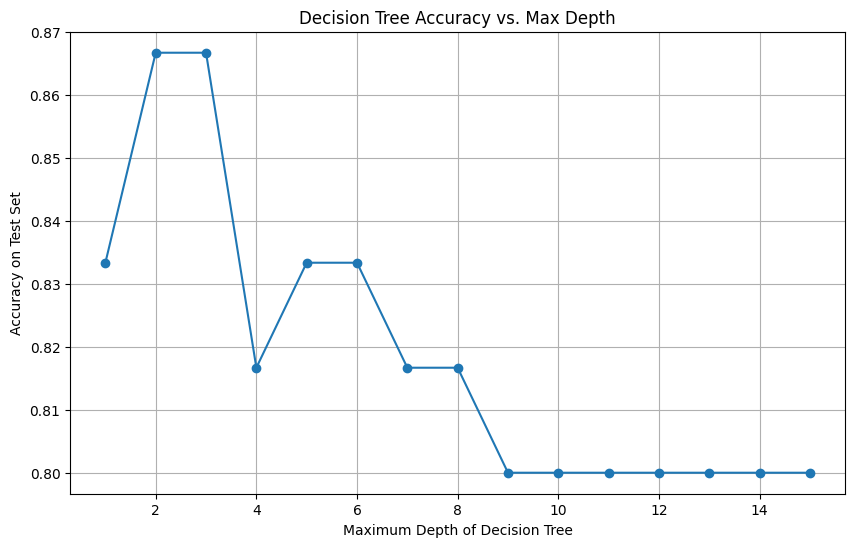

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(max_depth_values, accuracy_scores, marker='o')
plt.xlabel('Maximum Depth of Decision Tree')
plt.ylabel('Accuracy on Test Set')
plt.title('Decision Tree Accuracy vs. Max Depth')
plt.grid(True)
plt.show()

## Visualize decision boundaries for selected `max depth` values

### Subtask:
Visualize the decision boundaries for a few selected `max_depth` values.


**Reasoning**:
Visualize the decision boundaries for selected `max_depth` values (1, 5, 10) by training a classifier for each depth, creating a meshgrid, predicting classes on the meshgrid, plotting the contour, and scattering the training data.



## Summarize findings

### Subtask:
Present the results from the accuracy plot and decision boundary visualizations to explain the impact of `max_depth` on the model.


## Summary:

### Data Analysis Key Findings

*   The highest accuracy on the test set was observed at a `max_depth` of 2 and 3, both achieving an accuracy of 0.8667.
*   The accuracy generally increased from `max_depth` 1 to `max_depth` 2/3 and then fluctuated, showing a slight decrease and subsequent increases, indicating a potential peak in performance around smaller depths.
*   Visualizing decision boundaries showed that:
    *   A `max_depth` of 1 results in a simple, linear decision boundary.
    *   A `max_depth` of 5 creates a more complex, non-linear boundary.
    *   A `max_depth` of 10 results in a highly complex boundary that closely fits the training data, suggesting potential overfitting.

### Insights or Next Steps

*   The optimal `max_depth` for this dataset appears to be around 2 or 3, balancing complexity and generalization.
*   Further analysis could involve cross-validation to more robustly determine the optimal `max_depth` and evaluate model performance across different data splits.
